In [ ]:

from typing import Any, Dict, List, Optional

from pydantic import BaseModel

from agente_avaliacao_imagens.schemas import AnaliseImagens, FeedbackImagens


class ReActInput(BaseModel):
    """Entrada do agente ReAct de análise de imagens."""

    fotos_urls: List[str] = []
    api_key: Optional[str] = None

c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from phoenix.otel import register

tracer_provider = register(
  project_name="agente-react-imoveis",
  auto_instrument=True
)

08/05/2026 01:31:42 PM 📋 Ensuring phoenix working directory: C:\Users\jefer\.phoenix
08/05/2026 01:31:48 PM setup plugin alembic.autogenerate.schemas
08/05/2026 01:31:48 PM setup plugin alembic.autogenerate.tables
08/05/2026 01:31:48 PM setup plugin alembic.autogenerate.types
08/05/2026 01:31:48 PM setup plugin alembic.autogenerate.constraints
08/05/2026 01:31:48 PM setup plugin alembic.autogenerate.defaults
08/05/2026 01:31:48 PM setup plugin alembic.autogenerate.comments


OpenTelemetry Tracing Details
|  Phoenix Project: agente-react-imoveis
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: https://app.phoenix.arize.com/s/sehnemjeferson/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {'authorization': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\phoenix\otel\otel.py:433: UserWarning: Could not infer collector endpoint protocol, defaulting to HTTP.
  warnings.warn("Could not infer collector endpoint protocol, defaulting to HTTP.")


In [3]:
import logging
from typing import List

from langchain_core.tools import tool

from agente_avaliacao_imagens.prompts import PROMPT_DESCREVER_FOTO
from agente_avaliacao_imagens.utils import processar_todos_lotes

logger = logging.getLogger(__name__)


@tool
async def descrever_fotos(fotos_urls: List[str]) -> str:
    """Processa as fotos do imóvel e devolve a descrição técnica de cada imagem.

    Use esta ferramenta para obter a descrição das fotos. Depois, com base nela,
    preencha a análise estruturada final (scores, problemas, pontos fortes).

    Args:
        fotos_urls: lista de URLs das fotos do imóvel.
    """
    if not fotos_urls:
        return "Nenhuma URL de foto fornecida."
    
    logger.info(f"Processando {len(fotos_urls)} fotos para descrição.")

    descricao = await processar_todos_lotes(fotos_urls, 5, prompt=PROMPT_DESCREVER_FOTO)
    if not descricao:
        logger.error("Nao foi possivel descrever as fotos.")
        return "Falha ao descrever as fotos."
    return descricao

In [14]:
import json
import logging
import os
from typing import List, Optional

from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langgraph.prebuilt import create_react_agent

from agente_avaliacao_imagens.schemas import AnaliseImagens
#from .tools import descrever_fotos

logger = logging.getLogger(__name__)

MODELO_AGENTE = os.getenv("MODELO_AGENTE_IMAGENS",
                          #"z-ai/glm-5.2"#V
                          "meta/llama-3.1-8b-instruct"V
                          #"nvidia/nemotron-3-ultra-550b-a55b" #V
                          # "google/gemma-4-31b-it" X
                          #"poolside/laguna-xs-2.1" #X
                          #"qwen/qwen-2.5-72b-instruct" #X
                          ) #"moonshotai/kimi-k2.6")"deepseek-ai/deepseek-v4-flash")

SYSTEM_PROMPT = """Você é um engenheiro civil e especialista em avaliação de imóveis para house flipping.

Sua tarefa é analisar as fotos de um imóvel e produzir um relatório técnico estruturado.

Passos:
1. Chame a ferramenta `descrever_fotos` com as URLs das fotos. Ela devolverá a descrição técnica de cada imagem.
2. Analise a descrição recebida e preencha a análise estruturada final com os campos abaixo.

Definição de cada campo do relatório final:

- **score_conservacao (float 0-10):** condição geral de conservação/mainutenção do que está visível (infiltrações, trincas, desgaste, estado de paredes/teto).
- **score_acabamento (float 0-10):** qualidade/padrão dos materiais (piso, revestimentos, metais, portas, esquadrias).
- **score_potencial_reforma (float 0-10):** o quanto é viável/vantajoso reformar o espaço (nota alta = boa estrutura que valoriza com melhorias; nota baixa = exige demolição pesada ou já está em ótimo estado).
- **confianca_imagem (float 0-10):** o quanto a descrição é confiável, clara e útil para uma avaliação técnica.
- **imagem_aceitavel (bool):** `true` se a foto mostra elementos reais do imóvel e é clara; `false` se for irrelevante (selfie, parede escura, objeto aleatório) ou a descrição for vaga demais.
- **problemas_visiveis (List[str]):** patologias, defeitos, danos ou sinais de desgaste identificados. Vazio se não houver.
- **pontos_fortes (List[str]):** aspectos positivos observados (iluminação natural, piso em bom estado, acabamento moderno, área espaçosa). Vazio se não houver.
- **observacoes (str):** resumo da opinião técnica. Se `imagem_aceitavel = false` ou as notas forem baixas, use este campo para justificar tecnicamente.

Regras importantes:
- Baseie-se APENAS na descrição fornecida pela ferramenta. Nunca invente ou infira o que não está visível.
- Se um aspecto não puder ser avaliado, pondere as notas de forma neutra e registre a limitação em `observacoes`.
- Se as fotos não retratarem um ambiente de imóvel (imagem irrelevante/ilegível), marque `imagem_aceitavel = false`, atribua `0.0` a todos os scores e explique em `observacoes`.
- Responda SEMPRE em português.
"""


def criar_agente_imagens(api_key: Optional[str] = None):
    model = ChatNVIDIA(
        model=MODELO_AGENTE,
        api_key=api_key or os.getenv("NVIDIA_API_KEY"),
    )
    return create_react_agent(
        model=model,
        tools=[descrever_fotos],
        prompt=SYSTEM_PROMPT,
        response_format=AnaliseImagens,
    )


async def analisar_imagens(
    fotos_urls: List[str],
    api_key: Optional[str] = None,
) -> AnaliseImagens:
    """Executa o agente ReAct de análise de imagens e devolve o relatório estruturado."""
    agente = criar_agente_imagens(api_key=api_key)

    mensagem_usuario = {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Analise as fotos do imóvel:\n"
                    + json.dumps(fotos_urls, ensure_ascii=False, indent=2)
                ),
            }
        ]
    }

    resultado = await agente.ainvoke(mensagem_usuario)
    resposta = resultado.get("structured_response")

    if isinstance(resposta, dict):
        return AnaliseImagens(**resposta)
    return resposta

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1975982450.py, line 16)

In [2]:
import pandas as pd
from pathlib import Path


cidade = 'joinville'

estado = 'sc'

BASE_DIR = Path.cwd().parent
PASTA_DADOS = BASE_DIR / 'dados' / cidade
df = pd.read_parquet(PASTA_DADOS / f'{cidade}_imoveis_limpo_2026-08.parquet')

In [ ]:
fotos = df['fotos'].iloc[6].tolist()

In [ ]:
fotos

['https://resizedimgs.zapimoveis.com.br/img/vr-listing/2be5cbec55da625c7063443f287d852b/apartamento-com-3-quartos-a-venda-105m-no-saguacu-joinville.webp?action=fit-in&dimension=870x707',
 'https://resizedimgs.zapimoveis.com.br/img/vr-listing/80f6aae4cdef3bb2baf1c8609934408b/apartamento-com-3-quartos-a-venda-105m-no-saguacu-joinville.webp?action=fit-in&dimension=870x707&seo=false',
 'https://resizedimgs.zapimoveis.com.br/img/vr-listing/532e18b9c870fd26cfc2a712304896ab/apartamento-com-3-quartos-a-venda-105m-no-saguacu-joinville.webp?action=fit-in&dimension=870x707&seo=false',
 'https://resizedimgs.zapimoveis.com.br/img/vr-listing/ed7f7a3d250cc07765b1d97fa3e94448/apartamento-com-3-quartos-a-venda-105m-no-saguacu-joinville.webp?action=fit-in&dimension=870x707&seo=false',
 'https://resizedimgs.zapimoveis.com.br/img/vr-listing/fa37d92847ba04c856f07049f497b1c3/apartamento-com-3-quartos-a-venda-105m-no-saguacu-joinville.webp?action=fit-in&dimension=870x707&seo=false',
 'https://resizedimgs.zap

In [ ]:
response

AnaliseImagens(score_conservacao=8.0, score_acabamento=8.0, score_potencial_reforma=5.0, confianca_imagem=8.5, imagem_aceitavel=True, problemas_visiveis=[], pontos_fortes=[' Fachada de edifício', 'Bom estado de conservação', 'Design contemporâneo'], observacoes='A imagem é redundante, repetindo a fachada exibida nas fotos 1 e 5[20, 39]. Analisa apenas o exterior do edifício, que não apresenta danos visíveis[37]. Ausência de informações sobre os ambientes internos do imóvel[41].')

In [2]:
import pandas as pd
import json

In [1]:
#df = pd.read_json('olx_alugueis.json', lines=True)
import pandas as pd
from pathlib import Path


cidade = 'joinville'

estado = 'sc'

BASE_DIR = Path.cwd().parent
PASTA_DADOS = BASE_DIR / 'dados' / cidade
df = pd.read_parquet(PASTA_DADOS / f'{cidade}_imoveis_limpo_2026-08.parquet')

#with open(PASTA_DADOS/ 'joinville_aluguel_olx_2026-08.json', 'r', encoding='utf-8') as f:
#df = json.load(f)

In [2]:
df

,url,titulo,metragem,banheiros,vagas,quartos,valor_imovel,condominio,endereco,iptu,...,tipo_imovel,lat,lng,preco_por_m2,faixa,p25_bairro,p50_bairro,p75_bairro,desvio_mediana,idade
0,https://www.imovelweb.com.br/propriedades/casa...,"Casa à venda em Joinville-SC, Jardim Paraíso: ...",48.0,1,2,2,320000.0,NaN,"Rua Nerides, 63, Jardim Paraíso, Joinville - SC",NaN,...,casa,-26.210829,-48.837895,6666.666667,medio_alto,861.111111,1527.777778,6666.666667,3.36,1.0
1,https://www.imovelweb.com.br/propriedades/casa...,Casa com 4 quartos no Iririú em Joinville,381.0,3,3,4,1100000.0,NaN,"Rua Coronel Vieira, Iririú, Joinville - SC",NaN,...,casa,-26.269330,-48.819542,2887.139108,medio_baixo,2777.777778,4166.666667,5671.641791,-0.31,28.0
2,https://www.imovelweb.com.br/propriedades/casa...,CASA,390.0,1,2,3,375000.0,NaN,"Aventureiro, Joinville - SC",NaN,...,casa,-26.243548,-48.810468,961.538462,barato,5452.054795,6779.262129,NaN,-0.86,20.0
3,https://www.imovelweb.com.br/propriedades/sobr...,SOBRADO,364.0,6,2,2,1600000.0,NaN,"Bucarein, Joinville - SC",NaN,...,casa,-26.314681,-48.838248,4395.604396,medio_alto,2880.434783,3949.152542,5416.666667,0.11,20.0
4,https://www.imovelweb.com.br/propriedades/casa...,Casa com 5 quartos no Boa Vista em Joinville,360.0,3,2,5,1200000.0,NaN,"Rua Prefeito Helmuth Fallgatter, Boa Vista, Jo...",NaN,...,casa,-26.297967,-48.820991,3333.333333,medio_baixo,2934.782609,4080.675422,6090.909091,-0.18,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25307,https://www.zapimoveis.com.br/imovel/venda-cas...,"Casa com 4 Quartos à venda, 220m² - Jardim Par...",220.0,3,2,4,450000.0,0.0,"Jardim Paraíso, Joinville - SC",0.0,...,casa,-15.773599,-47.890254,2045.454545,barato,2500.000000,4544.763908,5618.758142,-0.55,NaN
25308,https://www.zapimoveis.com.br/imovel/venda-cas...,"Casa com 2 Quartos à venda, 216m² - Floresta",216.0,2,3,2,750000.0,0.0,"Rua Ipumirim, 70 - Floresta, Joinville - SC",1398.0,...,casa,-26.339727,-48.851449,3472.222222,barato,4285.714286,5042.307692,6269.841270,-0.31,NaN
25309,https://www.zapimoveis.com.br/imovel/venda-apa...,"Apartamento com 3 Quartos à venda, 227m² - Ani...",227.0,4,3,3,2648089.0,0.0,"Rua Pernambuco, 173 - Anita Garibaldi, Joinvil...",0.0,...,apartamento,-26.311698,-48.851844,11665.590308,alto_padrao,7452.903892,8928.571429,10516.797014,0.31,NaN
25310,https://www.zapimoveis.com.br/imovel/venda-cob...,"Cobertura com 3 Quartos à venda, 212m² - América",212.0,5,3,3,1290000.0,1500.0,"América, Joinville - SC",NaN,...,apartamento,-26.290361,-48.853581,6084.905660,barato,8074.055517,10292.908657,12054.017806,-0.41,NaN


In [14]:
df_zap = pd.read_parquet(PASTA_DADOS / f'joinville_zap_2026-09_51_60.parquet')

In [15]:
df_zap.iloc[0].to_dict()

{'url': 'https://www.zapimoveis.com.br/imovel/venda-apartamento-2-quartos-com-interfone-anita-garibaldi-joinville-56m2-id-2884543720/?source=ranking%2Crp',
 'titulo': 'Apartamento com 2 Quartos à venda, 56m² - Anita Garibaldi',
 'metragem': '56 m²',
 'banheiros': '2',
 'vagas': '1',
 'quartos': '2',
 'valor_imovel': None,
 'condominio': 'R$\xa0350/mês',
 'endereco': 'Anita Garibaldi, Joinville - SC',
 'iptu': 'Não informado',
 'descricao': 'LINDO APARTAMENTO NO ANITA GARIBALDI | SUÍTE + 01 DORMITÓRIO | 01 VAGA DE GARAGEM | CONDOMÍNIO COMPLETO\n\nEMPREENDIMENTO:\n\n- Ótima localização\n- Hall de entrada com pé direito duplo\n- Piscina\n- Lounge lareira\n- Espaço pet\n- Vagas com previsão para carros elétrico\n- Lavanderia coletiva\n- Wifi instalado em cada andar\n- Elevador chamado por aplicativo\n\nO APARTAMENTO \n\n- 56,21 m²\n- 01 suíte + 01 dormitório\n- 01 vaga de garagem\n- Piso porcelanato em todo o apartamento \n- Tomadas USB\n- Sacada com churrasqueira a carvão\n- Rebaixo em ge

In [39]:
df_idade = df[df['idade'].notna()]

In [40]:
df_idade['tipo_imovel'].value_counts()

tipo_imovel
apartamento    511
casa           428
outros          24
terreno         16
comercial        4
galpao           1
Name: count, dtype: int64

C:\Users\jefer\AppData\Local\Temp\ipykernel_15276\525499859.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_idade['idade'] = df_idade['idade'].astype(int)


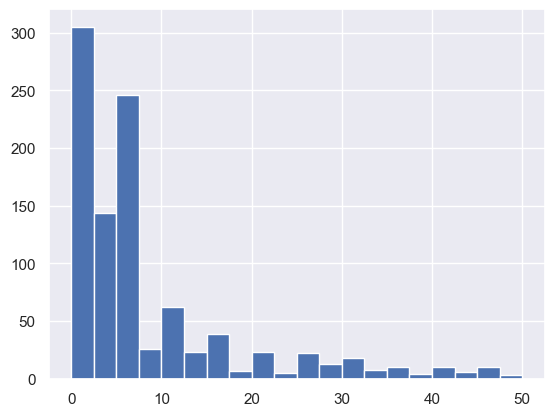

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="darkgrid")

df_idade['idade'] = df_idade['idade'].astype(int)
df_idade['idade'].hist(bins=20)
plt.show()

In [42]:
df.columns

Index(['url', 'titulo', 'metragem', 'banheiros', 'vagas', 'quartos',
       'valor_imovel', 'condominio', 'endereco', 'iptu', 'descricao',
       'data_criacao', 'caracteristicas', 'fotos', 'fonte', 'rua', 'numero',
       'bairro', 'cidade', 'estado', 'cep', 'dias_publicacao', 'tipo_imovel',
       'lat', 'lng', 'preco_por_m2', 'faixa', 'p25_bairro', 'p50_bairro',
       'p75_bairro', 'desvio_mediana', 'idade'],
      dtype='object')

C:\Users\jefer\AppData\Local\Temp\ipykernel_15276\3747551898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_idade['preco_por_m2'] = df_idade['preco_por_m2'].replace([np.inf, -np.inf], np.nan)


<Axes: >

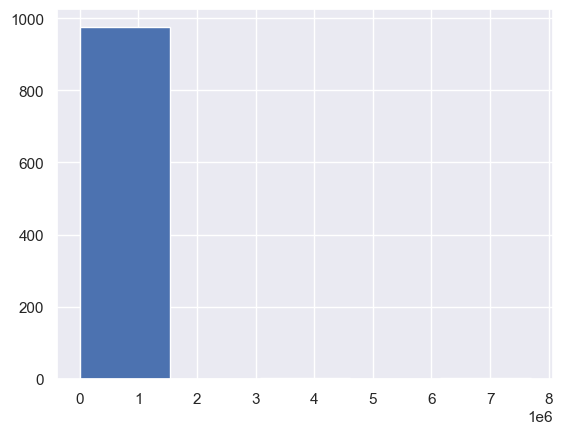

In [43]:
df_idade['preco_por_m2'] = df_idade['preco_por_m2'].replace([np.inf, -np.inf], np.nan)
df_idade['preco_por_m2'].astype(float).hist(bins=5)


Removidos: 0


C:\Users\jefer\AppData\Local\Temp\ipykernel_15276\1508176613.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_idade[col] = pd.to_numeric(df_idade[col], errors='coerce')


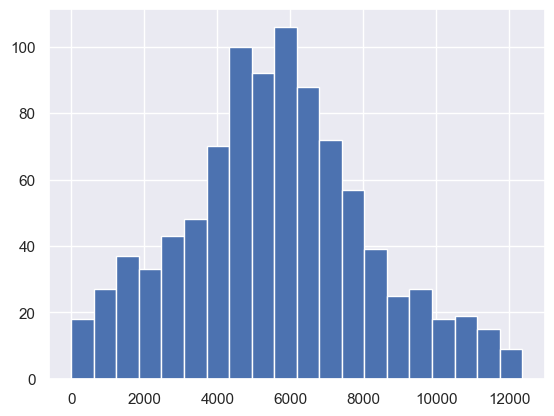

In [44]:
import numpy as np

col = 'preco_por_m2'
df_idade[col] = pd.to_numeric(df_idade[col], errors='coerce')

Q1 = df_idade[col].quantile(0.25)
Q3 = df_idade[col].quantile(0.75)
IQR = Q3 - Q1
mask = df_idade[col].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

df_idade = df_idade[mask]
print("Removidos:", len(df_idade) - len(df_idade))

df_idade[col].astype(int).hist(bins=20)
plt.show()

In [51]:
df_idade_apartamento = df_idade[df_idade['tipo_imovel'].isin(['apartamento'])]

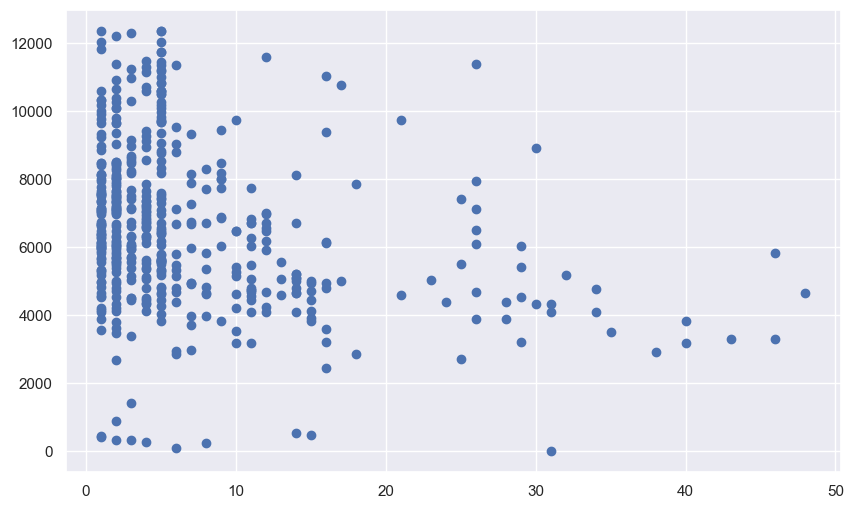

In [55]:
#idade por preco por metro quadrado
plt.figure(figsize=(10, 6))
plt.scatter(df_idade_apartamento['idade'], df_idade_apartamento['preco_por_m2'])
plt.show()

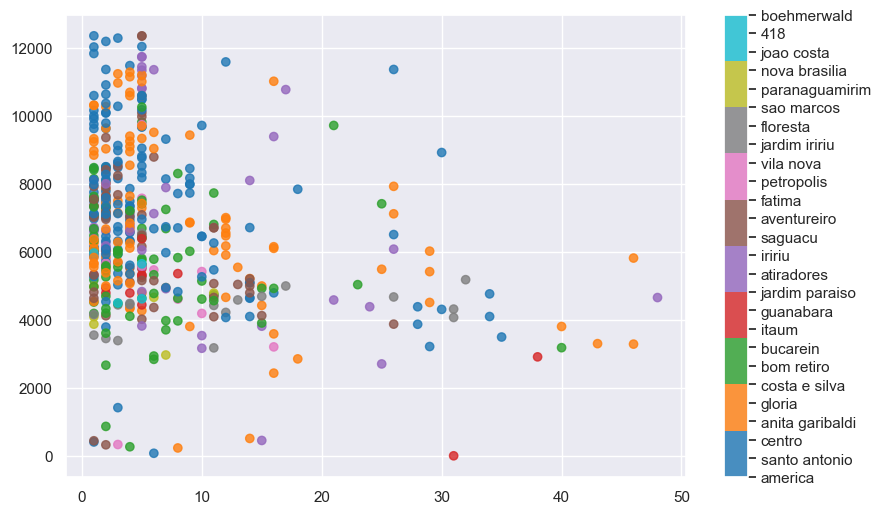

In [54]:
import matplotlib.pyplot as plt
import numpy as np
labels, uniques = pd.factorize(df_idade_apartamento['bairro'])
plt.figure(figsize=(10,6))
plt.scatter(df_idade_apartamento['idade'], df_idade_apartamento['preco_por_m2'],
            c=labels, cmap='tab10', alpha=0.8)
cbar = plt.colorbar(ticks=range(len(uniques)))
cbar.ax.set_yticklabels(uniques)
plt.show()

In [70]:
df_idade_apartamento.sort_values(by='idade')['url'].to_list()

['https://www.imovelweb.com.br/propriedades/apartamento-a-venda-em-guanabara-3028766313.html?n_src=Listado&n_exp=bianca_lead_flow_rollout-original&n_pills=Churrasqueira&n_pg=1&n_pos=28&n_search_id=53e1bbb9-8497-489b-8206-e86a49a836a5',
 'https://www.imovelweb.com.br/propriedades/apartamento-com-2-dormitorios-a-venda-58-m-por-r$-3002984626.html?n_src=Listado&n_exp=bianca_lead_flow_rollout-original&n_pills=Churrasqueira&n_pg=1&n_pos=1&n_search_id=53e1bbb9-8497-489b-8206-e86a49a836a5',
 'https://www.imovelweb.com.br/propriedades/costa-del-sol-2946086140.html?n_src=Listado&n_exp=bianca_lead_flow_rollout-original&n_pills=Varanda&n_pg=4&n_pos=27&n_search_id=0cb8cdea-f4f4-49f9-991a-8ba32d14ca2a',
 'https://www.imovelweb.com.br/propriedades/apartamento-com-2-dormitorios-a-venda-39-m-por-r$-3014374022.html?n_src=Listado&n_exp=bianca_lead_flow_rollout-original&n_pills=Churrasqueira&n_pg=2&n_pos=14&n_search_id=d75e6258-203d-46c2-b5c8-bd9c2fe0e503',
 'https://www.imovelweb.com.br/propriedades/apar

In [73]:
df_idade_apartamento['data_criacao'].value_counts()

Series([], Name: count, dtype: int64)

In [67]:
df_idade_apartamento['idade']

41      2
47      1
62     10
65      9
72     12
       ..
977     1
978     3
979     5
981     5
983     1
Name: idade, Length: 480, dtype: int64